In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("/content/train.csv")

In [11]:
df.shape

(891, 12)

In [12]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Why do EDA

• Model building  
• Analysis and reporting  
• Validate assumptions  
• Handling missing values  
• feature engineering  
• detecting outliers

Column Types
  1. Numerical  -- Age ,fare , passengerId
  2. Categorical -- Survived , pclass
  3. Mixed


Types of Analysis of Multiple Columns

  1. Univariate Analysis -- Analysis on single column
  2. Bivariate Analysis -- Analysis on two columns
  3. Multivariate Analysis -- Analysis on multiple columns

*   Further steps :
   Feature Engineering --> new columns --> outliers --> missing values
    











1.   Univariate Analysis

Univariate analysis focuses on analyzing each feature in the dataset independently.

• Distribution analysis: The distribution of each feature is examined to identify its shape, central tendency, and dispersion.

• Identifying potential issues: Univariate analysis helps in identifying potential problems with the data such as outliers, skewness, and missing values.

In univariate analysis, these three terms describe how a single variable behaves:

1. Shape
Describes the overall form of the data distribution.

Symmetric: Left and right sides are mirror images (e.g., normal distribution)
Skewed right (positive skew): Long tail on the right
Skewed left (negative skew): Long tail on the left
Modality:

Unimodal (one peak)
Bimodal (two peaks)

📊 Commonly visualized using histograms or density plots.

2. Central Tendency
Represents the center or typical value of the data.

Mean: Average of all values
Median: Middle value when data is sorted
Mode: Most frequent value

✅ Choice depends on data:

Use median when data has outliers or skewness
Use mean for symmetric data

3. Dispersion
  Shows how spread out the data is around the center.

  Range: Max − Min

  1. Variance: Average squared deviation from the mean
  2. Standard Deviation: Square root of variance (most common)
  3. Interquartile Range (IQR): Spread of the middle 50% of data

📉 Helps identify consistency, variability, and outliers.



1. Skewness is a statistical measure of the asymmetry of a data distribution. It identifies whether data points are concentrated on one side and "trail off" on the other.

2. Outliers are specific, extreme individual data points that lie an abnormal distance from the rest of the observations.

Age Column Univariate Analysis Conlusions:

 1. Distribution -- almost normal
 2. Missing values -- 20% missing values
 3. Few outliers detected

    Steps of doing Univariate Analysis on Numerical columns

    • Descriptive Statistics: Compute basic summary statistics for the column, such as mean, median, mode, standard deviation, range, and quartiles. These statistics give a general understanding of the distribution of the data and can help identify skewness or outliers.

    • Visualizations: Create visualizations to explore the distribution of the data. Some common visualizations for numerical data include histograms, box plots, and density plots. These visualizations provide a visual representation of the distribution of the data and can help identify skewness and outliers.

    • Identifying Outliers: Identify and examine any outliers in the data. Outliers can be identified using visualizations. It is important to determine whether the outliers are due to measurement errors, data entry errors, or legitimate differences in the data, and to decide whether to include or exclude them from the analysis.

    • Skewness: Check for skewness in the data and consider transforming the data or using robust statistical methods that are less sensitive to skewness, if necessary.

    • Conclusion: Summarize the findings of the EDA and make decisions about how to proceed with further analysis.



In [14]:
df["Age"].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


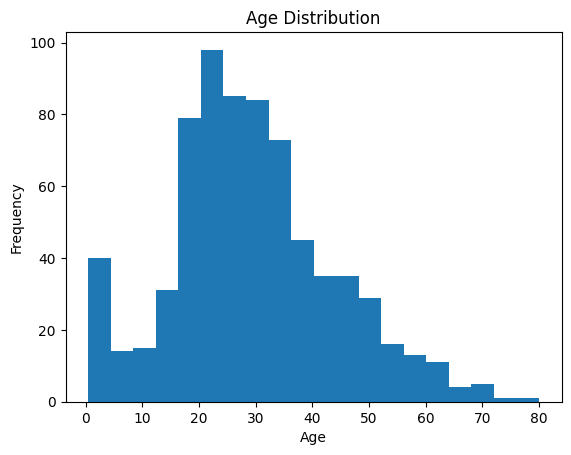

In [15]:
plt.hist(df["Age"].dropna(),bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

<Axes: ylabel='Density'>

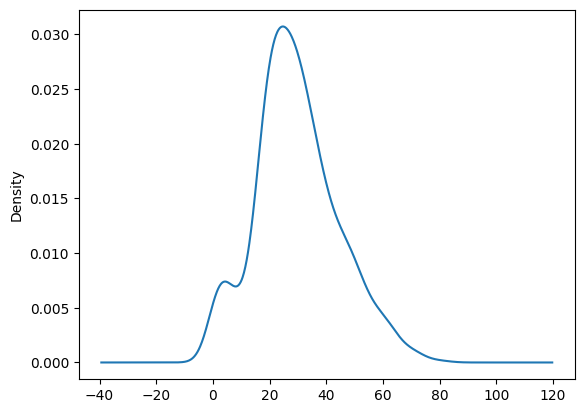

In [16]:
df["Age"].plot(kind="kde")

In [17]:
print(df["Age"].skew()) # -- as the value of skew is nearby zero the data is not skewed but close to normal

0.38910778230082704




> Add blockquote
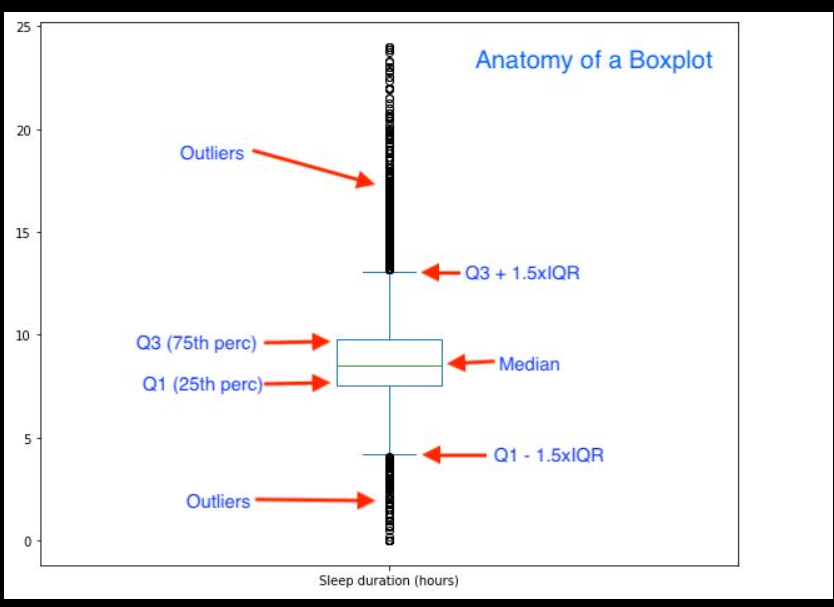


<Axes: >

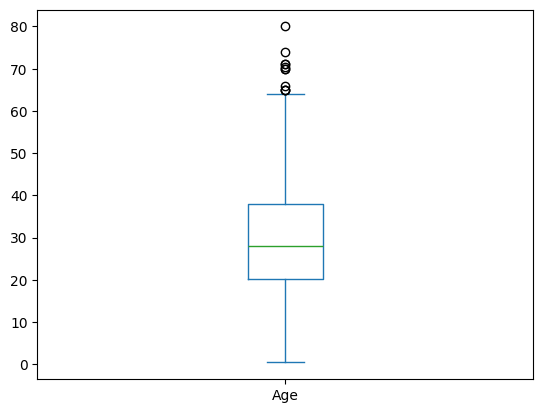

In [18]:
'''
Box plot -- The Five-Number Summary
  A box plot instantly visualizes five critical statistics:
  1. Minimum: The lowest value (excluding outliers).
  2. First Quartile (Q1): The 25th percentile (the bottom of the box).
  3. Median (Q2): The middle value (the line inside the box).
  4. Third Quartile (Q3): The 75th percentile (the top of the box).
  5. Maximum: The highest value (excluding outliers)
'''
df["Age"].plot(kind="box")


In [72]:
df[ df["Age"]>70 ]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type,Surname,Title,Deck
96,97,0.0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C,34.6542,1,Single,Goldschmidt,Mr.,A
116,117,0.0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,Missing,Q,7.7500,1,Single,Connors,Mr.,M
493,494,0.0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,Missing,C,49.5042,1,Single,Artagaveytia,Mr.,M
630,631,1.0,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S,30.0000,1,Single,Barkworth,Mr.,A
851,852,0.0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,Missing,S,7.7750,1,Single,Svensson,Mr.,M
96,988,NaN,1,"Cavendish, Mrs. Tyrell William (Julia Florence...",female,76.0,1,0,19877,78.8500,C46,S,39.4250,2,Small,Cavendish,Mrs.,C


In [20]:
missing_values=(df["Age"].isna().sum()/len(df["Age"]))*100
print(missing_values.round())

20.0


Univariate analysis on Fare Column

Summary Notes:

1. The data is skewed to the left
2. The box plot explains that there are so many outliers
3. In the fare column , family tickets(group tickets) are also included but we wanted individual fares of individuals
4.

In [21]:
df["Fare"].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


<Axes: ylabel='Frequency'>

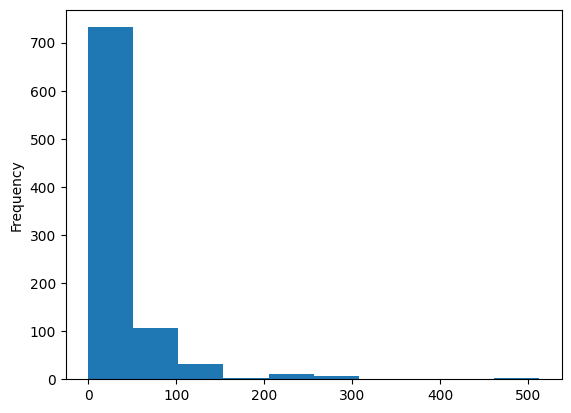

In [22]:
df["Fare"].plot(kind="hist")

4.787316519674893


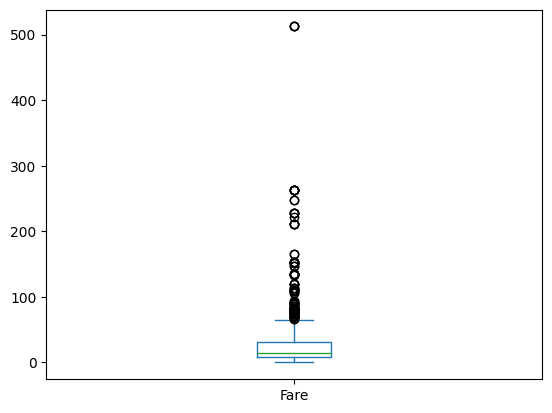

In [23]:
skewed=df["Fare"].skew()
df["Fare"].plot(kind="box")
print(skewed)

In [24]:
df[df["Fare"]>250]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


Univariate Analysis on Categorical Columns

Steps of doing univariate analysis:

1. Descriptive Statistics: Compute the frequency distribution of the categories in the column. This will give a general understanding of the distribution of the categories and their relative frequencies.

2. Visualizations: Create visualizations to explore the distribution of the categories. Some common visualizations for categorical data include count plots and pie charts. These visualizations provide a visual representation of the distribution of the categories and can help identify any patterns or anomalies in the data.

3. Missing Values: Check for missing values in the data and decide how to handle them. Missing values can be imputed or excluded from the analysis, depending on the research question and the data set.

Conclusion: Summarize the findings of the EDA and make decisions about how to proceed with further analysis.

**Survived Column Univariate Analysis Summary**
1. The bar graph shows that 549 people are dead and 342 were alive  
2. Pie chart shows us that 61.6 people survived
3. There are no outliers or null values
4. SibSp and Parch could be merged to form a new column
   "Family Size"

In [25]:
df["Survived"].value_counts()


,count
Survived,
0,549
1,342


<Axes: xlabel='Survived'>

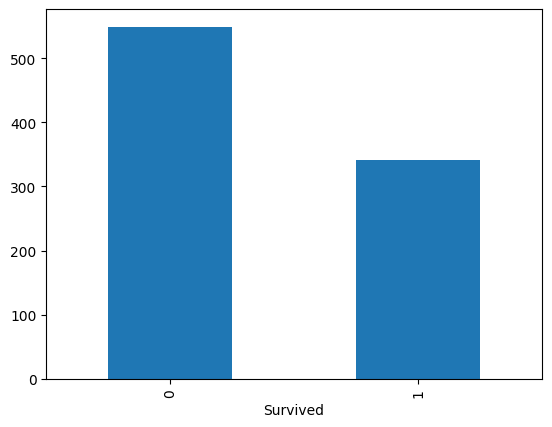

In [26]:
df["Survived"].value_counts().plot(kind="bar")

<Axes: ylabel='count'>

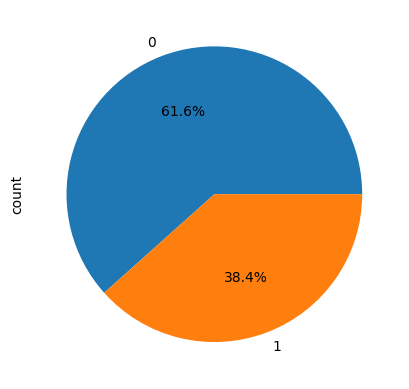

In [27]:
df["Survived"].value_counts().plot(kind="pie",autopct="%0.1f%%")

In [28]:
df["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


<Axes: xlabel='Pclass'>

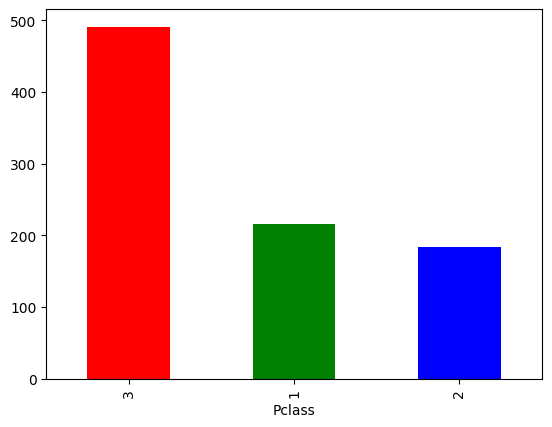

In [29]:
df["Pclass"].value_counts().plot(kind="bar",color=["red","green","blue"])

<Axes: ylabel='count'>

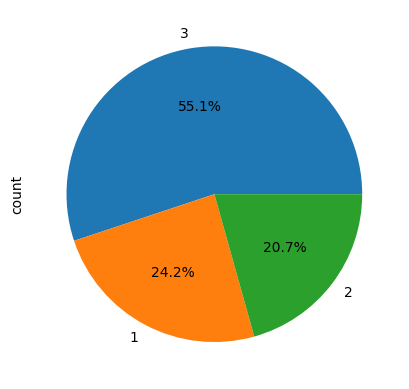

In [30]:
df["Pclass"].value_counts().plot(kind="pie",autopct="%0.1f%%")

In [31]:
null_count=df["Pclass"].isna().sum()
print(null_count)

0


In [32]:
# SibSp column indicates the number of siblings and spouses a passenger had onboard the Titanic.

df["SibSp"].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


<Axes: xlabel='SibSp'>

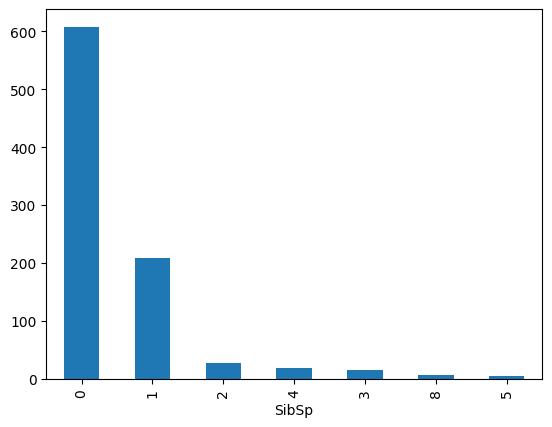

In [33]:
df["SibSp"].value_counts().plot(kind="bar")

<Axes: ylabel='count'>

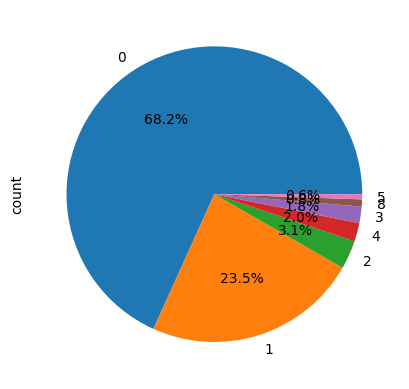

In [34]:
df["SibSp"].value_counts().plot(kind="pie",autopct="%0.1f%%")

**Bivariate Analysis**
1. Bivariate analysis means studying the relationship between two variables (columns) at a time to understand how they interact or affect each other.


1. Numerical – Numerical
(Both columns contain numbers)
📌 Examples:

Age & Fare
Height & Weight

What do we want to know?
👉 Does one number change when the other changes?
How do we analyze?

Scatter plot: Shows the relationship visually
Regression plot: Shows trend direction
Correlation coefficient: Tells how strongly they are related

📈 Interpretation:

Positive correlation → both increase together
Negative correlation → one increases, other decreases
No correlation → no clear pattern

2. Numerical – Categorical
(One column is numeric, the other is category)
📌 Examples:

Fare & Passenger Class
Age & Gender
Salary & Department

What do we want to know?
👉 How does the numerical value vary across categories?
How do we analyze?

Bar plot: Compare averages
Box plot: See spread, median, outliers
Violin plot: Distribution shape
KDE plot: Smooth distribution

📦 Interpretation:

Which category has higher/lower values?
Are there outliers in certain categories?


3. Categorical – Categorical
(Both columns are categories)
📌 Examples:

Survived & Gender
Class & Embarked

What do we want to know?
👉 How categories interact with each other?
How do we analyze?

Crosstab / Contingency table: Counts combinations
Heatmap: Easy visual comparison
Stacked bar plots: Proportions
Treemaps: Category distribution

📊 Interpretation:

Which category combination is most common?
Are some categories strongly related?


✅ Step 3: Write your conclusions
This is the most important step.
You summarize:

What relationship you observed
Whether the relationship is strong or weak
Patterns, trends, or surprising insights

📌 Example:

“Passengers in higher classes paid higher fares and had better survival rates.”


🔁 Simple One-Line Summary

Bivariate analysis = pick two columns → identify their data types → use appropriate plots/stats → draw conclusions

**Bivariate Analysis on Survived and Pclass Summary**
1. People travelling in higher class have higher chances of survival

In [35]:
# Bivariate Analysis on Survived and Pclass

pd.crosstab(df["Survived"],df["Pclass"])

Pclass,1,2,3
Survived,,,
0,80,97,372
1,136,87,119


In [75]:
'''
What is Normalization in EDA?
Normalization is the process of scaling numerical features to a common range so that they are comparable.
'''
pd.crosstab(df["Survived"],df["Pclass"],normalize="columns")*100

Pclass,1,2,3
Survived,,,
0.0,37.037037,52.717391,75.763747
1.0,62.962963,47.282609,24.236253


<Axes: xlabel='Survived', ylabel='Age'>

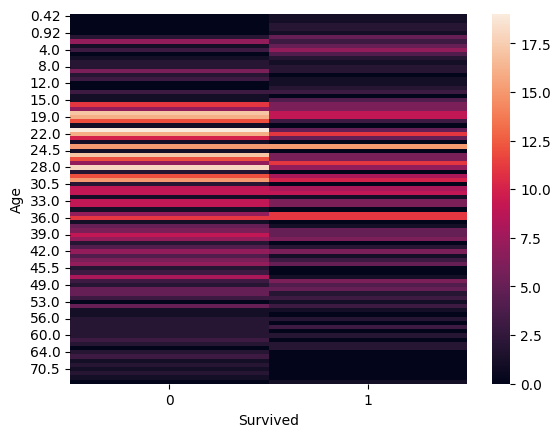

In [37]:
sns.heatmap(pd.crosstab(df["Age"],df["Survived"]))

Sex          female       male
Survived                      
0         25.796178  81.109185
1         74.203822  18.890815


<Axes: xlabel='Sex', ylabel='Survived'>

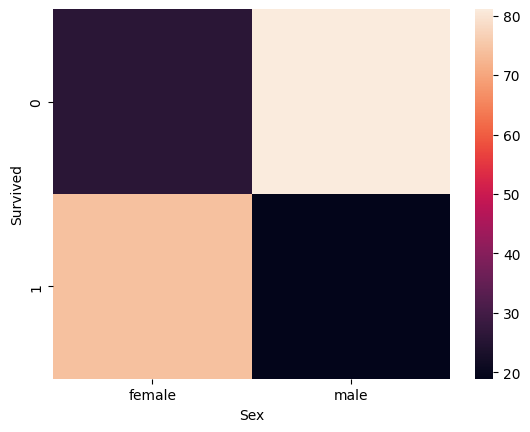

In [38]:
print(pd.crosstab(df["Survived"],df["Sex"],normalize="columns")*100)
sns.heatmap(pd.crosstab(df["Survived"],df["Sex"],normalize="columns")*100)

Embarked          C          Q          S
Survived                                 
0         44.642857  61.038961  66.304348
1         55.357143  38.961039  33.695652


<Axes: xlabel='Embarked', ylabel='Survived'>

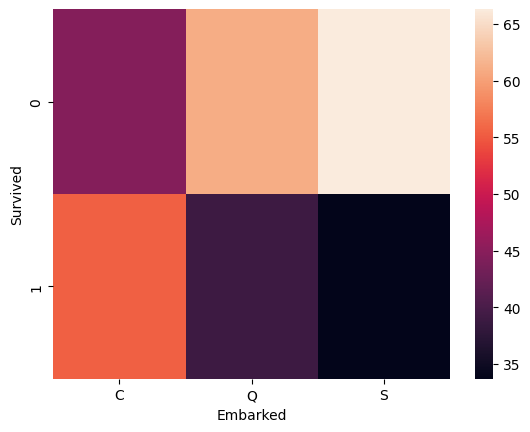

In [39]:
print(pd.crosstab(df["Survived"],df["Embarked"],normalize="columns")*100)
sns.heatmap(pd.crosstab(df["Survived"],df["Embarked"],normalize="columns")*100)

In [40]:
pd.crosstab(df["Sex"],df["Embarked"],normalize="columns")*100

Embarked,C,Q,S
Sex,,,
female,43.452381,46.753247,31.521739
male,56.547619,53.246753,68.478261


In [41]:
'''
Bivariate Analysis on Age and Survival

Does Age influence the probability of survival?
Are children more likely to survive?
Is survival skewed toward a particular age range?
Are there outliers or unusual age patterns among survivors?
'''

'\nBivariate Analysis on Age and Survival\n\nDoes Age influence the probability of survival?\nAre children more likely to survive?\nIs survival skewed toward a particular age range?\nAre there outliers or unusual age patterns among survivors?\n'

In [42]:
pd.crosstab(df["Age"],df["Survived"])

Survived,0,1
Age,,
0.42,0,1
0.67,0,1
0.75,0,2
0.83,0,2
0.92,0,1
...,...,...
70.00,2,0
70.50,1,0
71.00,2,0


<Axes: xlabel='Survived', ylabel='Age'>

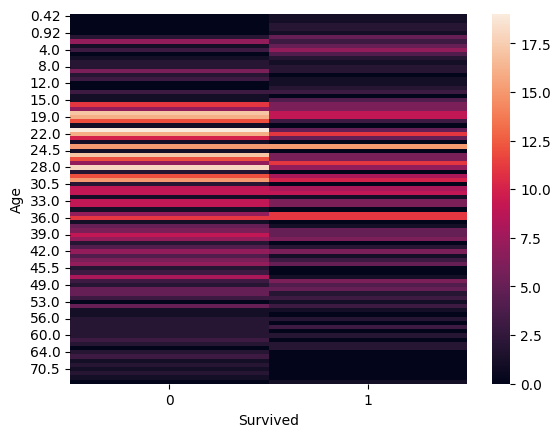

In [43]:
sns.heatmap(pd.crosstab(df["Age"],df["Survived"]))

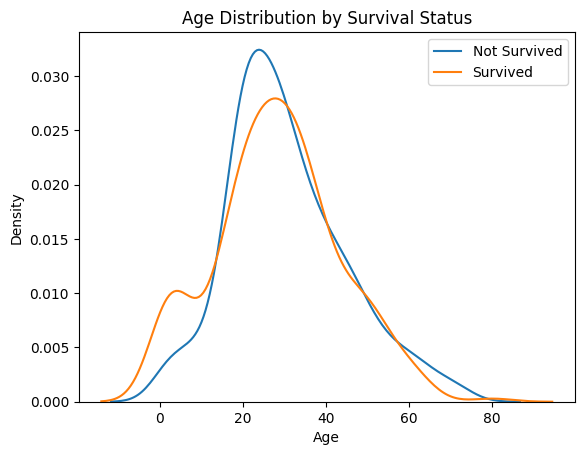

In [44]:
sns.kdeplot(df[df['Survived'] == 0]['Age'], label='Not Survived')
sns.kdeplot(df[df['Survived'] == 1]['Age'], label='Survived')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

In [45]:
df[df["Ticket"]=="C.2343"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [46]:
df["SibSp"].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


In [47]:
df[df["SibSp"]==8]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [48]:
df[df["Ticket"]=="CA. 2343"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [49]:
df1 = pd.read_csv("/content/test.csv")
df1.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [50]:
df=pd.concat([df,df1])

In [51]:
print(df.describe())
df.shape

       PassengerId    Survived       Pclass          Age        SibSp  \
count  1309.000000  891.000000  1309.000000  1046.000000  1309.000000   
mean    655.000000    0.383838     2.294882    29.881138     0.498854   
std     378.020061    0.486592     0.837836    14.413493     1.041658   
min       1.000000    0.000000     1.000000     0.170000     0.000000   
25%     328.000000    0.000000     2.000000    21.000000     0.000000   
50%     655.000000    0.000000     3.000000    28.000000     0.000000   
75%     982.000000    1.000000     3.000000    39.000000     1.000000   
max    1309.000000    1.000000     3.000000    80.000000     8.000000   

             Parch         Fare  
count  1309.000000  1308.000000  
mean      0.385027    33.295479  
std       0.865560    51.758668  
min       0.000000     0.000000  
25%       0.000000     7.895800  
50%       0.000000    14.454200  
75%       0.000000    31.275000  
max       9.000000   512.329200  


(1309, 12)

In [52]:
df.describe()
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [76]:
df[df["Ticket"] == "CA. 2343"]
# print(df["Ticket"].value_counts())
print(df[df["Ticket"] == "CA 2144"])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type,Surname,Title,Deck
159,160,0.0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Master.,M
180,181,0.0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Miss.,M
201,202,0.0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Mr.,M
324,325,0.0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Mr.,M
792,793,0.0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Miss.,M
846,847,0.0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Mr.,M
863,864,0.0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Miss.,M
188,1080,NaN,3,"Sage, Miss. Ada",female,NaN,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Miss.,M
342,1234,NaN,3,"Sage, Mr. John George",male,NaN,1,9,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Mr.,M
360,1252,NaN,3,"Sage, Master. William Henry",male,14.5,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Master.,M


In [54]:
df["individual_fare"] = (df["Fare"])/(df["SibSp"]+df["Parch"]+1)

In [77]:
df[df["Ticket"]=="CA. 2343"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type,Surname,Title,Deck
159,160,0.0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Master.,M
180,181,0.0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Miss.,M
201,202,0.0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Mr.,M
324,325,0.0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Mr.,M
792,793,0.0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Miss.,M
846,847,0.0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Mr.,M
863,864,0.0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Miss.,M
188,1080,NaN,3,"Sage, Miss. Ada",female,NaN,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Miss.,M
342,1234,NaN,3,"Sage, Mr. John George",male,NaN,1,9,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Mr.,M
360,1252,NaN,3,"Sage, Master. William Henry",male,14.5,8,2,CA. 2343,69.55,Missing,S,6.322727,11,Large,Sage,Master.,M


In [55]:
df[["individual_fare","Fare"]].describe()

,individual_fare,Fare
count,1308.000000,1308.000000
mean,20.518215,33.295479
std,35.774337,51.758668
min,0.000000,0.000000
25%,7.452767,7.895800
50%,8.512483,14.454200
75%,24.237500,31.275000
max,512.329200,512.329200


In [56]:
def transform_family(num):
  if num==1:
    return "Single"
  elif num>2 and num<=4:
    return "Small"
  else:
    return "Large"



In [57]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.625000
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.641650
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.925000
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.550000
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,8.050000
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,108.900000
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,7.250000
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,8.050000


In [58]:
df['family_size'] = df['SibSp'] + df['Parch'] + 1
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.625000,2
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.641650,2
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.925000,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.550000,2
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.050000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,8.050000,1
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,108.900000,1
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,7.250000,1
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,8.050000,1


In [59]:
'''
family_type
1 - single
<3 - Medium
>3 - Large
'''
def transform_family_size(num):
  if num ==1 :
    return "Single"
  elif num == 2:
    return "Small"
  else:
    return "Large"



In [60]:
df["family_type"] = df["family_size"].apply(transform_family_size)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2,Small
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,Small
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1,Single
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,Small
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1,Single


In [61]:
pd.crosstab(df["Survived"],df["family_type"],normalize="columns")*100



family_type,Large,Single,Small
Survived,,,
0.0,53.367876,69.646182,44.720497
1.0,46.632124,30.353818,55.279503


In [98]:
df["Cabin"]

,Cabin
0,Missing
1,C85
2,Missing
3,C123
4,Missing
...,...
413,Missing
414,C105
415,Missing
416,Missing


In [62]:
# extracting surname
df["Surname"]=df["Name"].str.split(",").str.get(0)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type,Surname
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2,Small,Braund
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,Small,Cumings
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1,Single,Heikkinen
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,Small,Futrelle
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1,Single,Allen


In [63]:
# extracting title -- Mr or Mrs and other titles
df["Title"]=df["Name"].str.split(",").str.get(1).str.strip().str.split(" ").str.get(0)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type,Surname,Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2,Small,Braund,Mr.
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,Small,Cumings,Mrs.
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1,Single,Heikkinen,Miss.
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,Small,Futrelle,Mrs.
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1,Single,Allen,Mr.


In [89]:
df[(df["Sex"]=="female") & (df["Title"]=="Miss.")]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type,Surname,Title,Deck
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Missing,S,7.925000,1,Single,Heikkinen,Miss.,M
10,11,1.0,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,5.566667,3,Large,Sandstrom,Miss.,G
11,12,1.0,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,26.550000,1,Single,Bonnell,Miss.,C
14,15,0.0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,Missing,S,7.854200,1,Single,Vestrom,Miss.,M
22,23,1.0,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,Missing,Q,8.029200,1,Single,McGowan,Miss.,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,1294,NaN,1,"Gibson, Miss. Dorothy Winifred",female,22.0,0,1,112378,59.4000,Missing,C,29.700000,2,Small,Gibson,Miss.,M
408,1300,NaN,3,"Riordan, Miss. Johanna Hannah""""",female,NaN,0,0,334915,7.7208,Missing,Q,7.720800,1,Single,Riordan,Miss.,M
409,1301,NaN,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,Missing,S,4.591667,3,Large,Peacock,Miss.,M
410,1302,NaN,3,"Naughton, Miss. Hannah",female,NaN,0,0,365237,7.7500,Missing,Q,7.750000,1,Single,Naughton,Miss.,M


In [64]:
titles_to_replace = [
    'Rev.', 'Dr.', 'Col.', 'Major.', 'Don.', 'Capt.', 'the', 'Jonkheer.',
    'Dona.', 'Mlle.', 'Mme.', 'Ms.', 'Countess.', 'Lady.'
]
df['Title'] = df['Title'].replace(titles_to_replace, 'Other')

print(df['Title'].value_counts())

Title
Mr.        757
Miss.      260
Mrs.       197
Master.     61
Other       33
Sir.         1
Name: count, dtype: int64


In [65]:
df["Cabin"].fillna("Missing",inplace=True)
df["Cabin"].value_counts()

/tmp/ipykernel_2294/2504629099.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Cabin"].fillna("Missing",inplace=True)


,count
Cabin,
Missing,1014
C23 C25 C27,6
G6,5
B57 B59 B63 B66,5
F33,4
...,...
C39,1
B24,1
D40,1


In [66]:
df["Deck"]=df["Cabin"].str[0]
df["Deck"]

,Deck
0,M
1,C
2,M
3,C
4,M
...,...
413,M
414,C
415,M
416,M


In [67]:
# deck correlates with class
pd.crosstab(df["Deck"],df["Pclass"])

Pclass,1,2,3
Deck,,,
A,22,0,0
B,65,0,0
C,94,0,0
D,40,6,0
E,34,4,3
F,0,13,8
G,0,0,5
M,67,254,693
T,1,0,0


In [68]:
%pip install fastapi


In [69]:
from fastapi import FastAPI

dir(FastAPI)

['__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'add_api_route',
 'add_api_websocket_route',
 'add_event_handler',
 'add_exception_handler',
 'add_middleware',
 'add_route',
 'add_websocket_route',
 'api_route',
 'build_middleware_stack',
 'delete',
 'exception_handler',
 'get',
 'head',
 'host',
 'include_router',
 'middleware',
 'mount',
 'on_event',
 'openapi',
 'options',
 'patch',
 'post',
 'put',
 'route',
 'routes',
 'setup',
 'trace',
 'url_path_for',
 'websocket',
 'websocket_route']